# Independent component analysis

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Be able to use ICA;
- Understand the difference between PCA and ICA;
- Understand the properties ICA;
- Understand the limitations ICA;
- Understand how ICA can be used for cleaning of data (e.g., from artefacts).

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import FastICA

## (Optional) Exercise 1: applications of ICA
1. Find an interesting application of ICA and post a link to it (e.g., the blog post, article, podcast, video, etc.) on the Brightspace assignment forum of Week 04. Describe the application in several sentences. As the subject of your post, use a sensible title that explains the body: i.e., use a title like `group $<$number$>$: $<$your application$>$', where you fill in your group and the application you found.
1. Try to dig deep into your application. Please answer questions that come up on the forum. We might also ask you to answer questions that come up during the flipped-classroom session.
1. Interact with other groups by commenting on their posts. Elaborate on why you think their application is an interesting one (or not); would you want to know more about it (what and why)? Are there any parts that are unclear to you? Do you have any suggestions (e.g., other related sources of information)? Etc.

## Exercise 2: the difference between _uncorrelated_ and _statistical independence_
The goal of this exercise is to understand the difference between _uncorrelated_ and _statistical independent_ data sets.

In the previous assignment, you have seen that principal component analysis (PCA) finds a set of __orthogonal (uncorrelated)__ basis vectors pointing in the directions of maximal variance of the data set. Formally, two random variables $\mathbf X$ and $\mathbf Y$ are defined to be uncorrelated $:\Longleftrightarrow$ their covariance $\bf \operatorname{cov}(X,Y) = E(XY) − E(X)E(Y)$ is zero. Now, remember the Pearson's correlation coefficient:

$\begin{equation} \bf \rho_{X,Y}= \frac{\operatorname{cov}(X,Y)}{\sigma_X \sigma_Y} \end{equation}$

If you compare the definition of uncorrelated and the definition of the correlation coefficient, you can easily see that two random variables with non-zero variance are uncorrelated $\Longleftrightarrow$ their correlation coefficient is zero. 

Independent component analysis (ICA) on the other hand is trying to find a set of basis vectors which are __statistically independent__. On an intuitive level, statistical independence between $\mathbf X$ and $\mathbf Y$ means that information about the outcome of $\mathbf X$ does not change the probability of the outcome of the other variable $\mathbf Y$. More rigorously, two random variables $\mathbf X$ and $\mathbf Y$ with cumulative distribution functions $F_X(x)$ and $F_Y(y)$, and probability density function $f_X(x)$ and $f_Y(y)$, are independent $\Longleftrightarrow$ the combined random variable $(\mathbf X, \mathbf Y)$ has a joint cumulative distribution function $F_{X,Y}(x,y)$ satisfying:

$\begin{equation} F_{X,Y}(x,y) = F_X(x) F_Y(y) \end{equation}$

1. Which of the data sets in (x,y) are uncorrelated? Which are statistically independent? Which of the two properties is stronger? **Hint:** The correlation coefficient is zero (and thus X, Y are uncorrelated) if the slope of a linear fit is zero.

![title](data/Independence.png)

Uncorrelated: 1d, all of 2nd row (2a-g)    
Correlated: Rest of row 1)

Statistically Independent: 1d, 2b and 2g    
Statistically Dependent: All of row 1) except 1d and from 2nd row 2a, 2c, 2d, 2e, 2f

Statistical independence is a stronger property. That is because correlation only gives information about the linear relationship of the variables (fit of the graph), but there may be still non-linear dependencies. Statistical independence can define the dependence of two variables even if it is non-linear. Moreover, independence always implies uncorrelation but not vice versa.

## Exercise 3: basics about ICA
Next, we want to cover the basics of ICA. ICA is a computational method for separating a multivariate signal (e.g. sounds) into (independent) additive subcomponents (e.g. speakers or singers). The standard model for ICA for the same number of sources and signals is:

\begin{equation} 
\mathbf x = \mathbf {A s}
\end{equation}

where $\mathbf x=(x_i,...x_D)$ is a column vector with the observations (e.g. in time) $\mathbf x_i \in \mathbb R^T$, $\mathbf s=(s_1,...s_D)$ is the source vector containing the original components $\mathbf s_i \in \mathbb R^T$ and $\mathbf A \in \mathbb R^{D \times D}$ is a linear transformation that defines the linear mixing of the constituent signals. Typically, $\mathbf A$ and $\mathbf s$ are unknown.

1. What are the central assumptions for the ICA to work? 

1. The sources mix linearly into the observations.
1. The sources are statistically independent at each time point t 
1. At least n-1 of the sources have a non-Gaussian distribution 

## Exercise 4: ambiguities in ICA
In comparison to PCA, ICA has two major ambiguities:
1. We cannot determine the variances (energies) of the independent components;
2. We cannot determine the order of the independent components.

Answer the following:
1. Why do these ambiguities occur? **Hint:** Answer this question by looking at the standard forward model $\mathbf x = \mathbf {As}$.

### Answer
In both cases the source vector $\mathbf{s}$ and the mixing matrix $\mathbf{A}$ are unknown quantities. Only the mixtures $\mathbf{x_i}$ are known which are a combination of the original sources. Therefore, we can freely change the order of the terms of the right side of the equation $\mathbf{x} = \mathbf{A}\mathbf{s}$. Or we can divide/multiply it by a scalar to fix the magnitudes of the independent components. These cases and "property" of the forward model equation lead to the underdetermination of the variances and order of the independent components.

## (Optional) Exercise 5:  FastICA and negentropy
Here, you will use an implementation of ICA which is called FastICA. It is an iterative fixed-point scheme which is minimizing the entropy (or equivalently maximizing the negative entropy (negentropy)) in order to find the independent components. 

The entropy of a random variable can be interpreted as the degree of information that the observation of the variable gives. The more “random”, i.e.  unpredictable and unstructured the variable is, the larger its entropy. 

1. Find out which special property the normal distribution has with respect to entropy for a fixed variance. How can this property be used for finding the independent components?

A more rigurous derivation can be found here: [Paper about ICA](https://www.cs.helsinki.fi/u/ahyvarin/papers/NN00new.pdf) in Chapter 4.

### Answer
A result that stems from information theory is that a Gaussian variable has the largest entropy among all random variables of equal variance. We also know from the Central Limit Theorem (CLT) that the independent sources are less Gaussian than their mixtures. Our goal in (Fast)ICA is to extremisize a metric of non-Gaussianity to identify the independent components and with the combination of the previous two principles by minimizing the entropy, relative to a Gaussian with fixed variance, we can achieve that.

## Exercise 6: preprocessing before ICA
Before applying ICA, most algorithms expect you to preprocess your data. Commonly, two preprocessing steps are applied before performing an ICA: __Centering__ and __Whitening__.

__Centering__ is done by simply subtracting the sample mean, i.e. $\bf x_c = x - \bar x$. This is equivalent to a translation of the data such that they are positioned around the origin.

__Whitening__ is a transformation that converts the data such that it has an identity covariance matrix. Let $\hat \Sigma$ be the estimated covariance matrix. Then $\bf x_w = \hat \Sigma^{-\frac{1}{2}} x_c$ would be the new whitened vector with zero mean and identity covariance matrix. 

One popular method for whitening is to use the eigenvalue decomposition (EVD) of the covariance matrix: $\bf \hat \Sigma = EDE^T$ where ${\bf E}$ is the orthogonal matrix of eigenvectors of $\hat \Sigma$ and ${\bf D}$ is the diagonal matrix of its eigenvalues, ${\bf D}= \text{diag}(d_1,...,d_D)$. Whitening can now be done by computing

$\begin{equation} {\bf x_w}={\bf E}{\bf D}^{-1/2}{\bf E}^T {\bf x_c} \end{equation}$

where the matrix ${\bf D}^{-1/2}$ is computed by a simple component-wise operation as ${\bf D}^{-1/2}=\text{diag}(d_1^{-1/2},...,d_D^{-1/2})$.

Below you see an implementation and the effect of centering and whitening.
1. Why is it useful to whiten the data?

[[1.00000000e+00 1.06224354e-15]
 [1.06224354e-15 1.00000000e+00]]


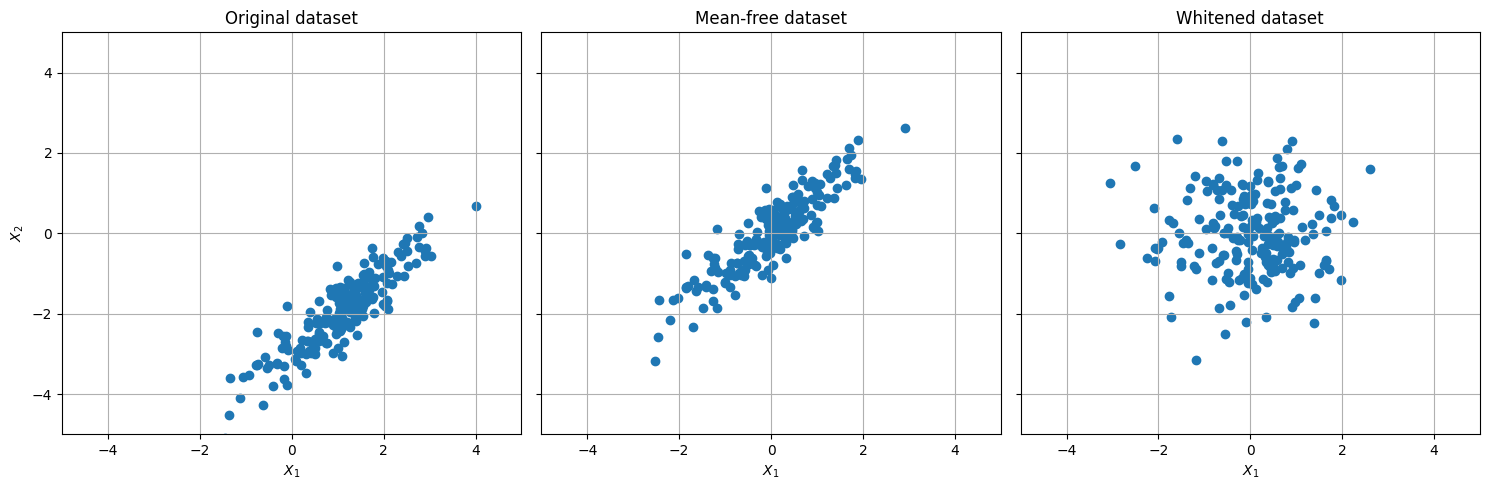

In [2]:
# Create normally distributed dataset
N_samples = 200;
X = np.random.multivariate_normal([1, -2], [[1, 0.9], [0.9, 1]], N_samples)

# Centering
mean = np.mean(X, axis=0)
X_meanfree = X - mean

# Whitening
cov = np.cov(X.T)
[D, E] = np.linalg.eig(cov)
D = np.diag(1 / np.sqrt(D))  # ^-1/2
X_white = np.dot(np.dot(np.dot(E, D), E.T), X_meanfree.T).T
# print(X_white.shape)
print(np.cov(X_white.T)) # Should be identity

# Draw the figure
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)    
for k in range(3):
    if k==0:
        X_temp = X
        ax[k].set_title('Original dataset')
    elif k == 1:
        X_temp = X_meanfree
        ax[k].set_title('Mean-free dataset')
    elif k == 2:
        X_temp = X_white 
        ax[k].set_title('Whitened dataset')           
    
    ax[k].scatter(X_temp[:, 0], X_temp[:, 1])
    ax[k].set_xlim([-5, 5])
    ax[k].set_ylim([-5, 5])
    ax[k].grid()
    ax[k].set_xlabel('$X_1$')
ax[0].set_ylabel('$X_2$')
fig.tight_layout()


### Answer
With the whitening method we managed to decorrelated the features and scale their variance to unit length. This makes the job easier for ICA since it is goal is to find the independent sources. Whitening removes the “easy” dependencies (mean and correlation), so ICA only needs to figure out the final rotation that makes the components independent.

## Exercise 7: blind source separation using FastICA
Imagine the following situation: there are three singers in a sound studio. Each of the singers ("sound source") generates a sound wave $s_{i}(t)$ over time $t$. The singers are surrounded by three microphones while each of those are recording the arriving sound $x_{j}(t)$. Given the observations of the three microphones $x_{j}(t), j=\{1,2,3\}$, we now want to compute a reconstruction of the contribution of each singer $s_{i,rec}(t)$ using an ICA model.

**Note:** In the following code, the true sources $S_{true}$ as well as the mixing matrix $A$ are given to generate the observations $X$. In a real world scenario, this would of course not be the case. Instead, you want to reconstruct the independent sources $S_{rec}$ and the estimated mixing matrix $\hat A$. This means we **ONLY** have access to our observations $X$.

1. Inspect the given generative model for constructing a data set of the above described scenario;
1. Train a FastICA model in order to reconstruct $s_{i,rec}(t)$ of each singer. You can use the FastICA implementation of the scikit-learn toolbox;
1. Visualize the observations $x_{j}(t)$ of every microphone, the reconstructed source signals $s_{i,rec}(t)$ and the true sources for all three components $s_{i,true}(t)$. Use the function `visualize_data()` as you need to do such kind of plots a few times within this exercise;
1. Compare the time series of the reconstructed sources with the true sources in terms of their order and sign. What do you observe?
1. Plot histograms of the estimated sources;
1. Verify the distribution of the estimated independent components. Which types of distributions do you expect the ICA to return?

In [3]:
def visualize_data(models, names):
    '''plot figure with subplot for each specified model, 
    in each subplot all three components are shown
    Input: list 'models', 'names' 
    Usage: visualize_data(models = [X, S_true], names = ['observations X', 'true sources'])
    '''
    colors = ['red', 'skyblue', 'orange']
    plt.figure(figsize=(12, 8))
    for i, (model, name) in enumerate(zip(models, names), 1):  # 1, X, observations X etc.
        plt.subplot(len(names), 1, i)  # subplot indexing start at 1
        plt.title(name, fontsize=15)
        plt.ylabel("Amplitude")
        plt.xlabel("Time point t")
        # plt.ylim(5,30)
        for sig, color in zip(model.T, colors):
            plt.plot(sig + i * 2 * max(sig), color=color)
    plt.subplots_adjust(0.09, 0.04, 0.94, 0.94, 0.26, 0.46)
    
# Generate sample data
np.random.seed(35)
N_samples = 2000
time = np.linspace(0, 8, N_samples)

# Singer 1: sinusoidal signal
s1 = np.sin(3 * time)  
# Singer 2: square signal
s2 = np.sign(np.sin(4 * time))
# Singer 3: saw tooth signal
s3 = signal.sawtooth(2 * np.pi * time)  

# Concatenate the true single sources and add noise 
S_true = np.c_[s1, s2, s3]
S_true += 0.5 * np.random.normal(size=S_true.shape)  

# Standardize the data
S_true /= S_true.std(axis=0) 

# Mix data
A = np.array([[1, 1, 1], [0.3, 2, 1.2], [1.5, 1.2, 2.4]])  # Mixing matrix
X = np.dot(S_true, A.T)
print(X.shape)

(2000, 3)


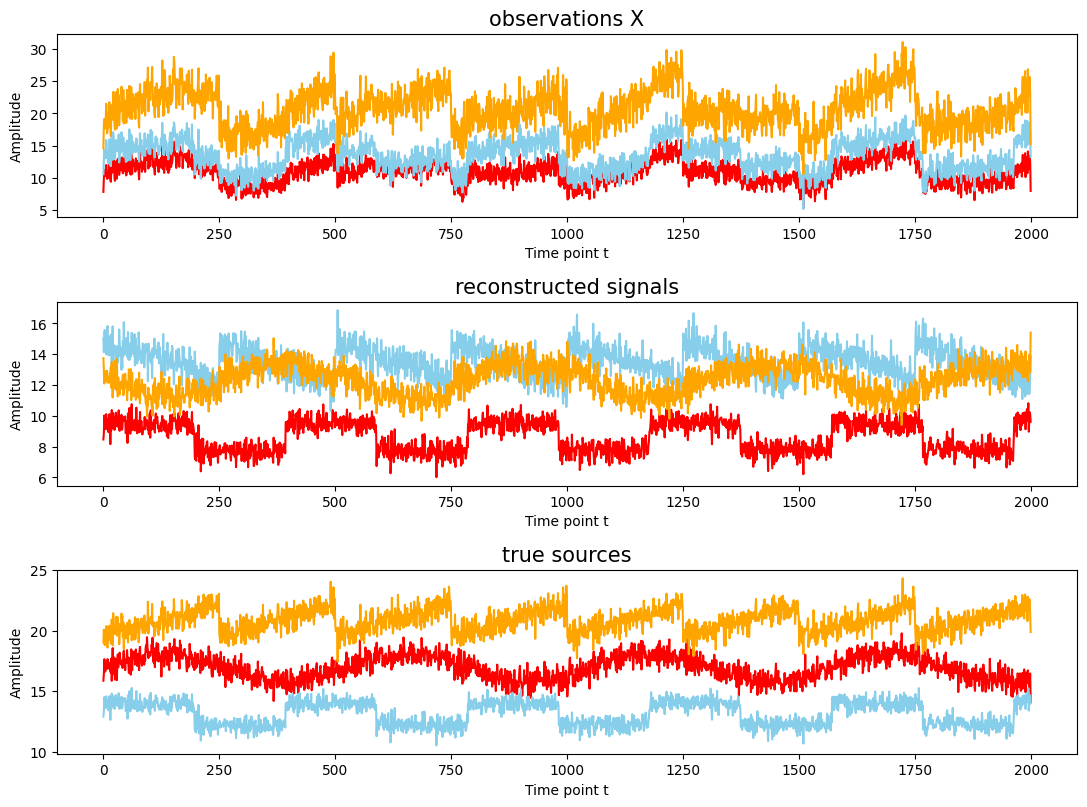

In [ ]:
# Compute ICA
# FastICA centers and whitens the data internally

ica = FastICA(n_components=3, whiten='unit-variance')
S_rec = ica.fit_transform(X)  # Reconstruct signals

visualize_data(models = [X, S_rec, S_true], names = ['observations X', 'reconstructed signals', 'true sources'])
plt.show() 
# colors = ['red', 'skyblue', 'orange']

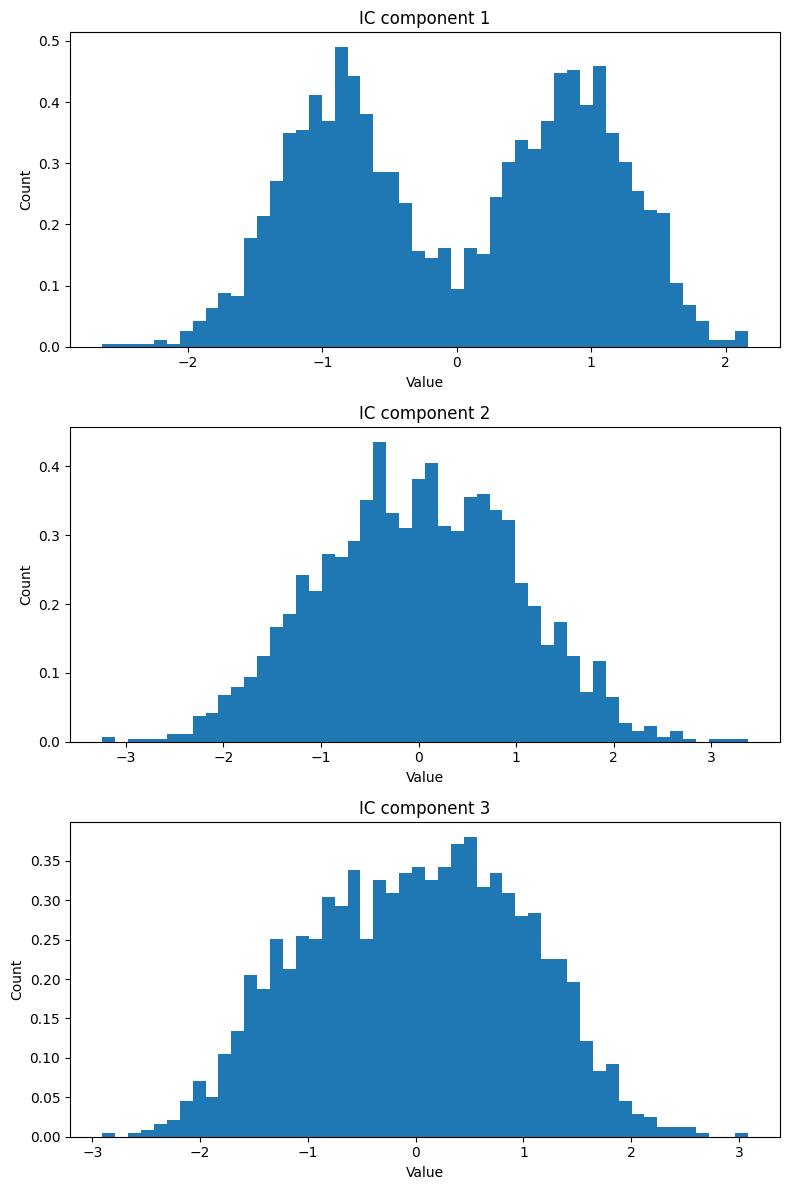

In [5]:
plt.subplots(3, 1, figsize=(8, 12))
for i in range(3):
    plt.subplot(3, 1, i+1)
    plt.hist(S_rec[:, i], density=True, bins=50)
    # plt.hist(S_true[:, i], bins=30, alpha=0.5)
    plt.title(f'IC component {i+1}')
    plt.xlabel('Value')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4)
When comparing the reconstructed sources with the true sources, we observe that the shapes of the signals are correctly recovered. However, the order of the sources is changed and some signals may appear with an inverted sign. Specifically, we can observe that the shapes do not correspond to the same colour in the reconstructed signals to the ones with the sources. Moreover, the top signal is inverted, has a different sign. This is know drawback of ICA because the mixing/unmixing process is underdetermined due to permutation and scaling of the components.

### 6)
One is bimodal (square wave), one is relatively flat (sawtooth/uniform-like), and one appears closer to Gaussian but is still not perfectly Gaussian due to the underlying sinusoidal source being smoothed by noise. This is consistent with the expectation that ICA returns maximally non-Gaussian components.  

## (Optional) Exercise 8: influence of data shuffling 
Now, we assume that the time information $t$ of the studio recording gets lost and verify the influence upon the ICA model.  
1. Generate a time-shuffled version of the observations $X_{shuffled}$. **Hint:** You can use the `np.random.permutation()` function to generate a permutation of timesteps $\{1, 2, ..., T\}$, which can be used to rearrange your dataset along one axis;
1. Compute an ICA model on the modified recordings $X_{shuffled}$ and un-shuffle the reconstructed independent sources $S_{rec,shuffled}$ such that it has the same temporal order as $S_{true}$. __Hint:__ You can use the `np.argsort()` function to invert the permutation you generated before;
1. Use the `visualize_data()` function to plot the reconstructed, unshuffled ICA-sources $S_{rec}$ and the true sources $S_{true}$;
1. Compare the reconstructed ICA-sources for the shuffled data and the non-shuffled data - can you give a reason for your observation?

**Note**: There are ICA variants that take temporal information into account to improve blind source separation of time series. See __[1](https://ieeexplore.ieee.org/document/554307/)__ and __[2](https://link.springer.com/chapter/10.1007/978-1-4471-1599-1_103)__ 

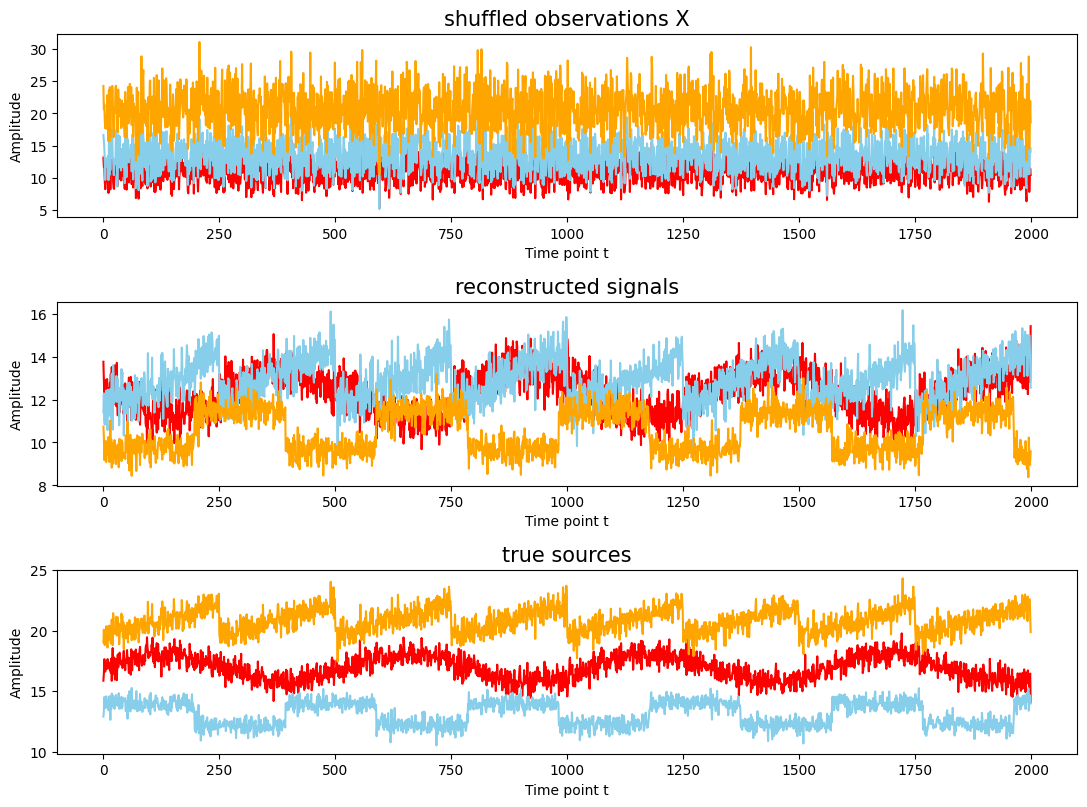

In [6]:
time_shuffled = np.random.permutation(2000)
X_shuffled = X[time_shuffled]

ica = FastICA(n_components=3, whiten='unit-variance')
S_recshuffled = ica.fit_transform(X_shuffled)  # Reconstruct signals
time_unshuffle = np.argsort(time_shuffled)
S_rec = S_recshuffled[time_unshuffle]

visualize_data(models = [X_shuffled, S_rec, S_true], names = ['shuffled observations X','reconstructed signals', 'true sources'])
plt.show() 

### 4)
When comparing the reconstructed sources for the shuffled data and the non-shuffled data, we observe that the shapes and the order of the signals are the same. However some signals may appear with an inverted sign between the reconstructed sources for the shuffled and non-shuffled data. The temperal information of the observations does thus not seem to make an impact on the reconstructed signals. 

## Exercise 9: remove ICA component from your observations
Now, we want to remove the contribution of two singers from the studio recordings $X$ such that only the contribution of singer 1 (sinusoidal waveform) remains. Therefore, you need to do the following steps:
1. Take the unmixing matrix $W=\hat A^{-1}$ of the component/s you want to keep and project the observation data $X$ to the  source space $S_{est}$;
2. Use the estimated mixing matrix $\hat A$ of the component/s you want to keep and project the reconstructed sources $S_{est}$ back to the observation space $X_{clean}$;
3. Visualize the cleaned observations $X_{clean}$, the original observations $X$ as well as the reconstructed sources $S_{est}$.

**Hint:** When selecting the components you want to remove from the observations, it might help to iteratively look at the cleaned observations $X_{clean}$ in order to see the effect.

**Hint:** When multiplying two vectors, think about your input and output dimensions. What kind of operation is required? Think about the inner product versus the outer product of two vectors.

**Note**: This procedure, removing ICA components from the data, is a useful one to remove (mixed) features (sources) from your data. In BCI, such "sources" could for instance be eye blinks, that have a clear spatial-temporal profile.

Mixing matrix
 [[-1.20645577  0.76083929 -1.09896781]
 [-0.59522828  1.09453243 -2.05889541]
 [-1.97929135  2.02541216 -1.37875085]]
Unmixing matrix:
 [[-1.48645971  0.65739627  0.20312676]
 [-1.81796798  0.28588005  1.02215072]
 [-0.53671598 -0.52377399  0.48466295]]
(2000, 3)


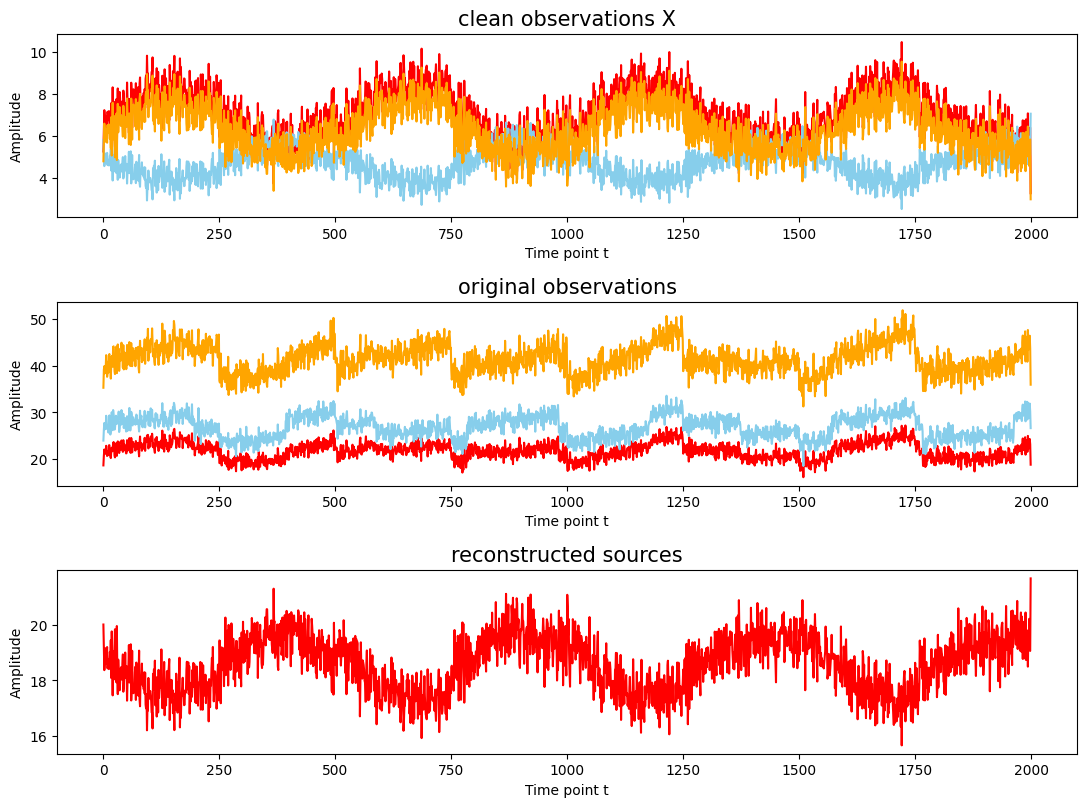

In [ ]:
A_ = ica.mixing_  # (n_features, n_components)
print("Mixing matrix\n", A_)
W_ = np.linalg.inv(A_)  # (n_components, n_features)
print("Unmixing matrix:\n", W_)

# W[:, 1:3] = 0  # project out by weight 0
W_s1 = W_[0, :]  # remove component
# print("Weight matrix s1:", W_s1)

S_est = np.dot(X, W_s1)

A_s1 = A_[0, :]
# print(A_s1)

S_est = S_est.reshape(-1,1)
A_s1 = A_s1.reshape(-1,1)

X_clean = np.dot(S_est, A_s1.T)  # (2000, 1) (3, 1).T
print(X_clean.shape)

visualize_data(models = [X_clean, X, S_est], names = ['clean observations X', 'original observations', 'reconstructed sources'])
plt.show() 

## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Exercise 2, 3, 4 - Jeroen Droog, Laurens Sloothaak, Petros Christodoulou (During workgroup)
> 
> Exercise 5, 6, 7 - Petros Christodoulou
> 
> Exercise 8 - Jeroen Droog
> 
> Exercise 9 - Jeroen Droog, Petros Christodoulou (During workgroup)